The numbers of hammer candlesticks identified is: 2



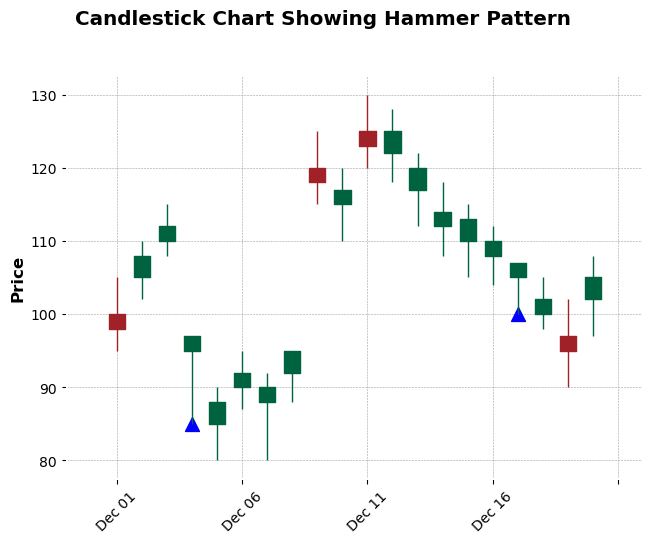

In [1]:
import pandas as pd
import mplfinance as mpf
from matplotlib import pyplot as plt

data = pd.DataFrame({
    'Open': [100, 105, 110, 95, 85, 90, 88, 92, 120, 115, 125, 122, 117, 112, 110, 108, 105, 100, 97, 102],
    'High': [105, 110, 115, 95, 90, 95, 92, 95, 125, 120, 130, 128, 122, 118, 115, 112, 106, 105, 102, 108],
    'Low': [95, 102, 108, 85, 80, 87, 80, 88, 115, 110, 120, 118, 112, 108, 105, 104, 100, 98, 90, 97],
    'Close': [98, 108, 112, 97, 88, 92, 90, 95, 118, 117, 123, 125, 120, 114, 113, 110, 107, 102, 95, 105]
})

data['Date'] = pd.date_range(start='2024-12-01', periods=len(data))
data.set_index('Date', inplace=True)

#identify hammer candlestick
def hammer(data, shadow_to_body_ratio=2.0):
    data['Real_Body'] = abs(data['Close'] - data['Open'])
    data['Lower_Shadow'] = data[['Open', 'Close']].min(axis=1) - data['Low']
    data['Upper_Shadow'] = data['High'] - data[['Open', 'Close']].max(axis=1)
    
    #will be a hammer when there is long lower shadow and little to no uppen shadow and there is non zero real body portion
    data['Hammer'] = ((data['Lower_Shadow'] >= shadow_to_body_ratio * data['Real_Body']) & (data['Upper_Shadow'] <= 0.1*data['Real_Body']) & (data['Real_Body'] > 0))
    return data


data = hammer(data)
num_hammers = data['Hammer'].sum()
print(f'The numbers of hammer candlesticks identified is: {num_hammers}')
print('')
#plot a candlestick chart showing hammer patterns
if data['Hammer'].sum() > 0:
    marker_series = pd.Series(index=data.index, data=None)
    marker_series[data['Hammer']] = data.loc[data['Hammer'], 'Low']

    hammer_markers = mpf.make_addplot(marker_series, type='scatter', marker='^', markersize=100, color='blue')

    # plot the chart
    fig, axes = mpf.plot(data, type='candle', style='charles', title='Candlestick Chart Showing Hammer Pattern', volume=False, addplot=hammer_markers, returnfig = True)
    # Move the y-axis to the left
    axes[0].yaxis.set_ticks_position('left')
    axes[0].yaxis.set_label_position('left')
else:
    print("No Hammer patterns found in the dataset.")
